# 3장 실습 — 스파이크 인코딩

**Spiking Neural Networks 쿡북 with Python** · 3장 실습 노트북

연속 데이터를 SNN이 먹을 수 있는 **스파이크 열**로 바꾸는 세 가지 방법(레이트·레이턴시·델타)을 `snntorch.spikegen`으로 직접 실험한다.

### 학습 목표
- `spikegen.rate`로 레이트 코딩을 만들고 래스터로 확인한다.
- `spikegen.latency`로 값이 클수록 일찍 발화하는 시점 코딩을 만든다.
- `spikegen.delta`로 변화에 반응하는 이벤트 코딩을 만든다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

`spikegen`은 인코딩 함수 모음이다.

In [1]:
import torch
from snntorch import spikegen        # 스파이크 인코딩 함수 모음
import matplotlib.pyplot as plt
import koreanize_matplotlib           # 그래프 한글 폰트

torch.manual_seed(0)                 # 재현성

## 2. 레이트 코딩 — `spikegen.rate`

0~1 사이 값을 발화 확률로 보고, `num_steps` 동안 매 스텝 베르누이 시행으로 스파이크를 만든다. 여기서는 0부터 1까지 점점 커지는 10개의 값을 인코딩한다. 값이 큰 뉴런일수록 스파이크가 촘촘하다.

In [2]:
num_steps = 100
values = torch.linspace(0.0, 1.0, 10)        # 0~1까지 10개 값(밝기)
rate_spikes = spikegen.rate(
    values, 
    num_steps=num_steps
)   # (num_steps, 10)

print('출력 형태:', tuple(rate_spikes.shape))
print('값별 평균 발화율:', [round(r, 2) for r in rate_spikes.mean(0).tolist()])

출력 형태: (100, 10)
값별 평균 발화율: [0.0, 0.13, 0.28, 0.31, 0.43, 0.56, 0.65, 0.8, 0.9, 1.0]


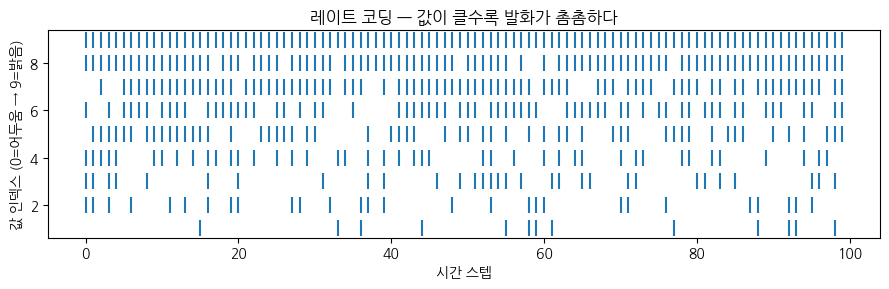

In [3]:
# 래스터 플롯: 각 값(뉴런)이 시간에 따라 언제 발화하는지
fig, ax = plt.subplots(figsize=(9, 3))
for n in range(rate_spikes.shape[1]):
    times = torch.where(rate_spikes[:, n] > 0)[0].numpy()
    ax.scatter(times, [n] * len(times), marker='|', s=120, color='tab:blue')
ax.set_xlabel('시간 스텝')
ax.set_ylabel('값 인덱스 (0=어두움 → 9=밝음)')
ax.set_title('레이트 코딩 — 값이 클수록 발화가 촘촘하다')
plt.tight_layout()
plt.show()

## 3. 레이턴시 코딩 — `spikegen.latency`

값이 클수록 **더 일찍** 단 한 번 발화한다. 먼저 발화 시점 공식 `t = τ·ln(x / (x − θ))`을 곡선으로 보고, 같은 값들을 `spikegen.latency`로 인코딩해 비교한다.

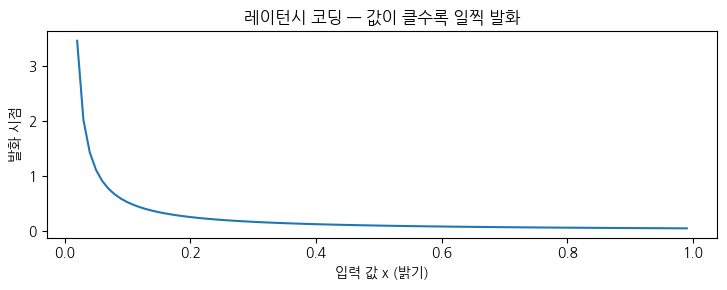

In [4]:
# 발화 시점 공식을 곡선으로 확인
x = torch.arange(0.02, 1.0, 0.01)
tau, threshold = 5.0, 0.01
spike_time = tau * torch.log(x / (x - threshold))   # 값→발화 시점

plt.figure(figsize=(7.5, 3))
plt.plot(x.numpy(), spike_time.numpy(), color='tab:blue')
plt.xlabel('입력 값 x (밝기)')
plt.ylabel('발화 시점')
plt.title('레이턴시 코딩 — 값이 클수록 일찍 발화')
plt.tight_layout()
plt.show()

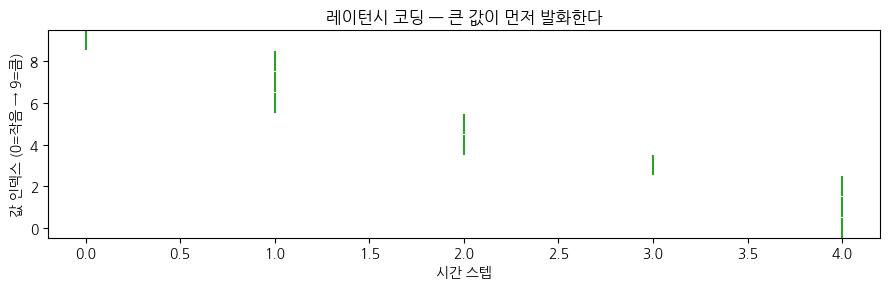

In [5]:
# 실제 인코딩: 큰 값일수록 왼쪽(이른 시점)에서 발화
values = torch.linspace(0.1, 1.0, 10)
lat_spikes = spikegen.latency(
    values, 
    num_steps=100, 
    tau=5, 
    threshold=0.01, 
    linear=True
)

fig, ax = plt.subplots(figsize=(9, 3))
for n in range(lat_spikes.shape[1]):
    times = torch.where(lat_spikes[:, n] > 0)[0].numpy()
    ax.scatter(times, [n] * len(times), marker='|', s=200, color='tab:green')
ax.set_xlabel('시간 스텝')
ax.set_ylabel('값 인덱스 (0=작음 → 9=큼)')
ax.set_title('레이턴시 코딩 — 큰 값이 먼저 발화한다')
plt.tight_layout()
plt.show()

## 4. 델타 변조 — `spikegen.delta`

값 자체가 아니라 **이전 스텝 대비 변화량**이 임계값을 넘을 때만 발화한다. 시계열을 만들어 인코딩하면 값이 크게 변하는 지점에서만 스파이크가 찍히는 것을 볼 수 있다.

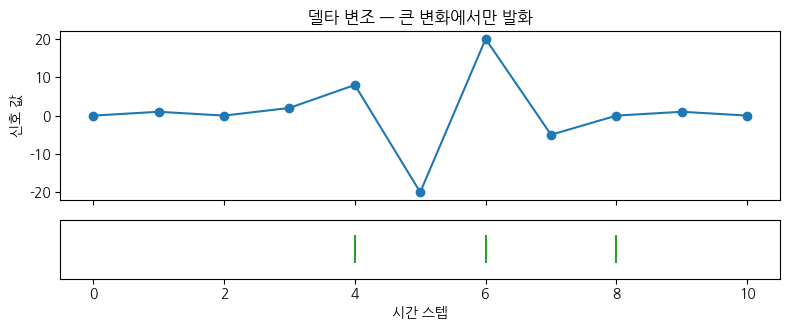

In [6]:
# 가상의 시계열 데이터
data = torch.Tensor([0, 1, 0, 2, 8, -20, 20, -5, 0, 1, 0])
delta_spikes = spikegen.delta(data, threshold=4)   # 변화가 4 이상일 때 발화

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 3.4), sharex=True,
                               gridspec_kw={'height_ratios': [2, 0.7]})
ax1.plot(data.numpy(), marker='o', color='tab:blue')
ax1.set_ylabel('신호 값')
ax1.set_title('델타 변조 — 큰 변화에서만 발화')

spike_times = torch.where(delta_spikes > 0)[0].numpy()
ax2.scatter(
    spike_times, 
    [0] * len(spike_times)
    , marker='|', 
    s=400, 
    color='tab:green'
)
ax2.set_yticks([])
ax2.set_xlabel('시간 스텝')
plt.tight_layout()
plt.show()

## 정리

- `spikegen.rate`: 값을 발화 확률로 → **빈도**에 정보를 싣는다.
- `spikegen.latency`: 값이 클수록 일찍 발화 → **시점**에 정보를 싣는다.
- `spikegen.delta`: 변화가 클 때만 발화 → **변화**에 정보를 싣는다.

다음 4장에서는 이렇게 만든 스파이크를 받아 처리하는 LIF 뉴런의 동역학을 더 깊이 다룬다.